# Notebook 05 — LSTM Decoder

**Key idea:**  
An MLP receives all 72 syndrome bits at once and treats them as independent features.
An LSTM processes them **round by round** — 9 time steps × 8 stabilisers — and carries
a hidden state that captures how errors propagate *across* rounds. This is the
temporal memory the paper arXiv:2502.20269 (Bödeker et al.) argues is essential.

**Architecture (from the paper, Table I):**
```
Input  : (batch, 9 rounds, 8 stabilisers)
LSTM 1 : 36 units, returns full sequence
LSTM 2 : 36 units, returns final hidden state only
Dense  : 48 → ReLU → Dropout(0.2)
Dense  : 24 → ReLU → Dropout(0.2)
Dense  : 12 → ReLU → Dropout(0.2)
Output :  1 → Sigmoid  (logical error probability)
```

**Prerequisites:** Run notebooks 01–04 first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import glob, os, time, warnings
warnings.filterwarnings('ignore')

SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

Device  : cuda
PyTorch : 2.10.0+cu128


---
## 1. Load & Reshape Data

Critical reshape: `(N, 72)` flat → `(N, 9, 8)` time series.

In [2]:
det = np.load("data/detection_events.npy").astype(np.float32)
obs = np.load("data/observable_flips.npy").astype(np.float32).squeeze()

ROUNDS      = 9
STABILISERS = 8

assert det.shape[1] == ROUNDS * STABILISERS, (
    f"Expected {ROUNDS*STABILISERS} detector columns, got {det.shape[1]}")

det_seq = det.reshape(-1, ROUNDS, STABILISERS)   # (N, 9, 8)

print("Data shapes:")
print(f"  Flat (MLP input)  : {det.shape}")
print(f"  Sequential (LSTM) : {det_seq.shape}  ← (N, rounds, stabilisers)")
print(f"  Labels            : {obs.shape}")
print()
print("The LSTM sees 8 syndrome bits at each of 9 time steps.")
print("Its hidden state accumulates information about error propagation across rounds.")

Data shapes:
  Flat (MLP input)  : (100000, 72)
  Sequential (LSTM) : (100000, 9, 8)  ← (N, rounds, stabilisers)
  Labels            : (100000,)

The LSTM sees 8 syndrome bits at each of 9 time steps.
Its hidden state accumulates information about error propagation across rounds.


---
## 2. Train / Val / Test Split

In [3]:
idx = np.arange(len(obs))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30,
                                    stratify=obs.astype(int), random_state=SEED)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50,
                                    stratify=obs[idx_tmp].astype(int), random_state=SEED)

seq_tr  = det_seq[idx_tr];   obs_tr  = obs[idx_tr]
seq_val = det_seq[idx_val];  obs_val = obs[idx_val]
seq_te  = det_seq[idx_te];   obs_te  = obs[idx_te]

trivial_ler = obs_te.mean()
print(f"Split  → train: {len(idx_tr):,}  val: {len(idx_val):,}  test: {len(idx_te):,}")
print(f"Trivial LER : {trivial_ler:.4f}  ({100*trivial_ler:.4f}%)")

Split  → train: 70,000  val: 15,000  test: 15,000
Trivial LER : 0.0549  (5.4867%)


---
## 3. LSTM Model Definition

In [4]:
class LSTMDecoder(nn.Module):
    """
    LSTM decoder for surface code — architecture from arXiv:2502.20269 Table I.
    Input : (batch, rounds=9, stabilisers=8)
    Output: (batch,) raw logit
    """
    def __init__(self, input_size=8, lstm_hidden=36, lstm_layers=2,
                 dense=[48, 24, 12], dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = lstm_hidden,
            num_layers  = lstm_layers,
            batch_first = True,
            dropout     = dropout if lstm_layers > 1 else 0.0,
        )
        layers, in_dim = [], lstm_hidden
        for h in dense:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim  = h
        layers.append(nn.Linear(in_dim, 1))
        self.head = nn.Sequential(*layers)

    def forward(self, x):
        # x: (batch, rounds, stabilisers)
        _, (h_n, _) = self.lstm(x)       # h_n: (num_layers, batch, hidden)
        out = h_n[-1]                     # last layer final hidden state
        return self.head(out).squeeze(-1) # (batch,)


def make_loader(X, y, batch_size=512, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


@torch.no_grad()
def predict(model, X, batch_size=1024):
    model.eval()
    ds     = TensorDataset(torch.tensor(X))
    loader = DataLoader(ds, batch_size=batch_size)
    preds  = []
    for (Xb,) in loader:
        logits = model(Xb.to(DEVICE))
        preds.append((torch.sigmoid(logits) > 0.5).cpu().numpy())
    return np.concatenate(preds)


demo  = LSTMDecoder()
total = sum(p.numel() for p in demo.parameters())
print(f"LSTM decoder: {total:,} parameters")
print(demo)

LSTM decoder: 20,545 parameters
LSTMDecoder(
  (lstm): LSTM(8, 36, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=36, out_features=48, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=24, out_features=12, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=12, out_features=1, bias=True)
  )
)


---
## 4. Train LSTM

In [5]:
model      = LSTMDecoder(input_size=STABILISERS).to(DEVICE)
optimizer  = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
pos_weight = torch.tensor([(1-obs_tr.mean()) / obs_tr.mean()]).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

tr_loader  = make_loader(seq_tr,  obs_tr)
val_loader = make_loader(seq_val, obs_val, shuffle=False)

EPOCHS, PATIENCE = 100, 12
history = {'tr_loss': [], 'val_loss': [], 'tr_ler': [], 'val_ler': []}
best_val_loss, best_epoch, best_state = np.inf, 0, None
t0 = time.time()

print("Training LSTM decoder...")
for epoch in range(1, EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for Xb, yb in tr_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # essential for LSTM stability
        optimizer.step()
        preds      = (torch.sigmoid(logits) > 0.5).float()
        tr_correct += (preds == yb).sum().item()
        tr_total   += len(yb)
        tr_loss    += loss.item() * len(yb)
    tr_loss /= tr_total
    tr_ler   = 1 - tr_correct / tr_total

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb  = Xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(Xb)
            loss    = criterion(logits, yb)
            preds   = (torch.sigmoid(logits) > 0.5).float()
            val_correct += (preds == yb).sum().item()
            val_total   += len(yb)
            val_loss    += loss.item() * len(yb)
    val_loss /= val_total
    val_ler   = 1 - val_correct / val_total

    scheduler.step(val_loss)
    for k, v in zip(['tr_loss','val_loss','tr_ler','val_ler'],
                    [tr_loss, val_loss, tr_ler, val_ler]):
        history[k].append(v)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}  tr_loss={tr_loss:.4f}  "
              f"val_loss={val_loss:.4f}  val_LER={val_ler:.5f}")

    if epoch - best_epoch >= PATIENCE:
        print(f"  Early stop at epoch {epoch} (best={best_epoch})")
        break

model.load_state_dict(best_state)
pred_lstm = predict(model, seq_te)
ler_lstm  = float((pred_lstm != obs_te).mean())

print(f"\nDone in {time.time()-t0:.1f}s | best epoch={best_epoch}")
print(f"  LSTM Test LER : {ler_lstm:.5f}  ({100*ler_lstm:.4f}%)")
print(f"  Trivial LER   : {trivial_ler:.5f}  ({100*trivial_ler:.4f}%)")
print(f"  Improvement   : {trivial_ler/ler_lstm:.1f}x")

Training LSTM decoder...
  Epoch   1  tr_loss=1.2063  val_loss=0.7866  val_LER=0.21460
  Epoch  10  tr_loss=0.2279  val_loss=0.2086  val_LER=0.09587
  Epoch  20  tr_loss=0.1543  val_loss=0.1392  val_LER=0.01500
  Epoch  30  tr_loss=0.1006  val_loss=0.1064  val_LER=0.01333
  Epoch  40  tr_loss=0.0867  val_loss=0.1043  val_LER=0.01233
  Epoch  50  tr_loss=0.0685  val_loss=0.0890  val_LER=0.01173
  Epoch  60  tr_loss=0.0643  val_loss=0.0848  val_LER=0.00987
  Early stop at epoch 67 (best=55)

Done in 98.2s | best epoch=55
  LSTM Test LER : 0.01087  (1.0867%)
  Trivial LER   : 0.05487  (5.4867%)
  Improvement   : 5.0x


---
## 5. LSTM Training Curves (Stim Style)

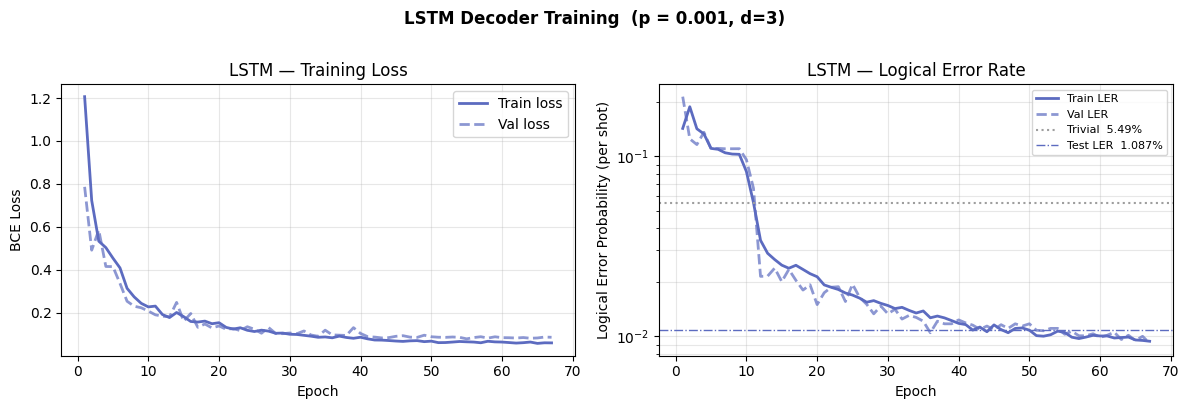

Saved → figures/05_lstm_training.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history['tr_loss'])+1)

ax1.plot(epochs, history['tr_loss'],  color='#5C6BC0', lw=2, label='Train loss')
ax1.plot(epochs, history['val_loss'], color='#5C6BC0', lw=2, ls='--', alpha=0.7,
         label='Val loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.set_title('LSTM — Training Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.semilogy(epochs, history['tr_ler'],  color='#5C6BC0', lw=2, label='Train LER')
ax2.semilogy(epochs, history['val_ler'], color='#5C6BC0', lw=2, ls='--', alpha=0.7,
             label='Val LER')
ax2.axhline(trivial_ler, color='#9E9E9E', lw=1.5, ls=':',
            label=f'Trivial  {100*trivial_ler:.2f}%')
ax2.axhline(ler_lstm, color='#5C6BC0', lw=1, ls='-.',
            label=f'Test LER  {100*ler_lstm:.3f}%')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Logical Error Probability (per shot)')   # Stim label
ax2.set_title('LSTM — Logical Error Rate')
ax2.legend(fontsize=8); ax2.grid(which='both', alpha=0.3)

plt.suptitle('LSTM Decoder Training  (p = 0.001, d=3)', fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig('figures/05_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/05_lstm_training.png")

---
## 6. LSTM Noise Sweep

In [7]:
NOISE_LEVELS = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]
lstm_lers    = []

print("LSTM noise sweep")
print(f"  {'p':>8}  {'Trivial':>10}  {'LSTM LER':>10}  {'Ratio':>7}")
print("  " + "-"*42)

for p in NOISE_LEVELS:
    tag   = f"{int(p*10000):04d}"
    det_s = np.load(f"data/sweep/det_p{tag}.npy").astype(np.float32)
    obs_s = np.load(f"data/sweep/obs_p{tag}.npy").astype(np.float32).squeeze()
    seq_s = det_s.reshape(-1, ROUNDS, STABILISERS)
    pred_s = predict(model, seq_s)
    ler_s  = float((pred_s != obs_s).mean())
    triv_s = float(obs_s.mean())
    lstm_lers.append(ler_s)
    ratio = triv_s / ler_s if ler_s > 0 else float('inf')
    print(f"  p={p:.4f}  {100*triv_s:8.3f}%  {100*ler_s:8.3f}%  {ratio:5.1f}x")

os.makedirs("results", exist_ok=True)
np.save("results/lstm_sweep.npy",
        np.array(list(zip(NOISE_LEVELS, lstm_lers))))
print("\nSaved → results/lstm_sweep.npy")

LSTM noise sweep
         p     Trivial    LSTM LER    Ratio
  ------------------------------------------
  p=0.0005     2.862%     0.294%    9.7x
  p=0.0010     5.272%     1.116%    4.7x
  p=0.0020    10.162%     3.776%    2.7x
  p=0.0050    22.114%    16.048%    1.4x
  p=0.0100    34.362%    33.908%    1.0x
  p=0.0200    45.250%    47.572%    1.0x

Saved → results/lstm_sweep.npy


---
## 7. Save Model

In [8]:
os.makedirs("models", exist_ok=True)
torch.save({
    'model_state': model.state_dict(),
    'input_size':  STABILISERS,
    'rounds':      ROUNDS,
    'lstm_hidden': 36,
    'lstm_layers': 2,
    'dense':       [48, 24, 12],
    'test_ler':    ler_lstm,
    'history':     history,
}, "models/decoder_lstm.pt")
print(f"Saved → models/decoder_lstm.pt  (test_ler={ler_lstm:.5f})")

Saved → models/decoder_lstm.pt  (test_ler=0.01087)
